# SVM BINARY CLASSIFIER FROM SCRATCH WITH JAX
SVMs are a supervised machine learning algorithms used for classification and regression tasks. They work by finding the optimal hyperplane that separates data points of different classes with the maximum margin.

As sci-kit learn is converting our jax.numpy inputs to numpy, we will implement a SVM model optimized for Jax from scratch.
# ___________________________________________


# SETUP 

In [ ]:
import sys
print(sys.executable)
print(sys.path)
import jax
import jax.numpy as np
sys.path.insert(0,"2526_INFOB318_Kernax/project/SVM")
from jax import jit
from functools import partial
from Kernax import LinearKernel, RBFKernel

# VARIABLES INITIALIZATION 
 So we are initializing the variables of our SVM here, based on the SVM known equation Wx + b =y.
 A parameters for the kernel used is also considered with an instance for the testing points(it is useful for the predict part
)

In [1]:
class SVM:

    def __init__(self, C = 1.0):
        # C = error term
        self.C = C
        self.w = 0
        self.b = 0
        self.kernel = None
        self.X_train = None  

# Hinge loss function
 The hinge loss function is useful for obtaining the best w and b parameters (which will be used to DEFINE our hyperplane) in the gradient descent algorithm, this function could be effectively be jitted as there is no control flow that depends on the static attributes of the inputs 

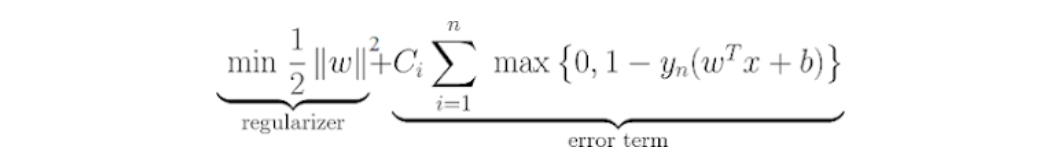

In [ ]:
@partial(jit, static_argnums=(0,))
def hingeloss(self, w, b, x, y):
        # Regularizer term
        reg = 0.5 * (w * w)

        for i in range(x.shape[0]):
            # Optimization term
            opt_term = y[i] * ((np.dot(w, x[i])) + b)
            # my problem here is that i need to know if 1-opt term is > 0 or not but at compile time i only know the shape
            # calculating loss
            # problem here, i could use cond from jax control flow to replace max
   
            loss = reg + self.C * np.maximum(0, 1-opt_term)
        return loss[0][0]


# Fit function
So basicaly, the fit function is the most important function in SVMs, it will find us the best w and b hyperparameters that will be used to define our hyperplane, basically, it will run a gradient descent algorithm on a matrix(that matrix could be a cov matrix) and labels. For the moment, only rbf and the basic linear kernel are considered.
For the moment the function couldn't be jitted but it will soon be.

# Fit function implementation
 The function can be more subdivided into more functions, it will be done.

In [ ]:

def fit(self, X, Y, batch_size=100, learning_rate=0.001, epochs=1000):
        self.X_train = X.copy()


    

        if(self.kernel == "rbf"):
            X = RBFKernel(length_scale = 2.0,variance=1.0)(X,X)
            print(X)
            print(type(X))
        # The number of features    
        number_of_features = X.shape[1]

        # The number of Samples in X
        number_of_samples = X.shape[0]

        c = self.C

        # Creating ids from 0 to number_of_samples - 1
        ids = np.arange(number_of_samples)
        key = jax.random.key(0)
        # Shuffling the samples randomly, entropy goes brrrrrr
        jax.random.permutation(key,ids)

        w = np.zeros((1, number_of_features))
        b = 0
        losses = []

        for i in range(epochs):
            # Calculating the Hinge Loss
            l = self.hingeloss(w, b, X, Y)

            # Appending all losses 
            losses.append(l)
            
            # Starting from 0 to the number of samples with batch_size as interval
            for batch_initial in range(0, number_of_samples, batch_size):
                gradw = 0
                gradb = 0

                for j in range(batch_initial, batch_initial+ batch_size):
                    if j < number_of_samples:
                        x = ids[j]
                        ti = Y[x] * (np.dot(w, X[x].T) + b)

                        if ti > 1:
                            gradw += 0
                            gradb += 0
                           
                        else:
                            # Calculating the gradients

                            #w.r.t w 
                            gradw += c * Y[x] * X[x]
                            # w.r.t b
                            gradb += c * Y[x]

                w = w - learning_rate * w + learning_rate * gradw
                b = b + learning_rate * gradb
             
        
        self.w = w
        self.b = b
        return self.w, self.b, losses            


# Gradient descent algorithm jit possibilites and details.

 Je n'ai pas réussi à jit la fonction parce que je ne vois pas comment je peux avoir deux types de retours diff avec cond et/ou select


                       #Pour pouvoir utiliser any, dans ma jax cond et donc pouvoir imiter ce comportement
                        #testing = np.greater(ti,comparator)
                        #gradw += jax.lax.cond(np.any(testing), lambda _ : c * Y[x] * X[x], lambda _: 0.0, None)
                        #gradb += jax.lax.cond(np.any(testing), lambda _ : c * Y[x] * X[x], lambda _: 0.0, None) 

                        
                        # here there might be a trick to do, to not modify gradw && gradb when ti > 1
                        # else on fait initial 

In [ ]:

#Predict 
